# Question 1 — multilevel descriptive analysis

This notebook moves from the broadest population view to the finest available evidence:

1. **London overall** — long-run composition, seasonality and COVID-period departures;
2. **Inner versus Outer London** — the size and source of the geographic gap;
3. **London boroughs** — persistence, change, context and spatial concentration;
4. **Respondents** — demographic inequalities before and after multivariable adjustment.

## 0. Load the prepared data once

The first notebook has already fixed the sample, weights and geographic definitions. Here the annual, quarterly and monthly files are split by `geography_level`; the respondent and age files are loaded only when their sections begin.

In [1]:
# Load libraries and the three frequency panels without creating output folders.
from pathlib import Path
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import spearmanr
import statsmodels.api as sm
import statsmodels.formula.api as smf

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 60)

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / 'question1_outputs').exists() else cwd.parent
DATA_DIR = PROJECT_ROOT / 'question1_outputs' / 'prepared_data'
EXTRA_DIR = PROJECT_ROOT / 'extradata'
PATHS = {
    'Annual': DATA_DIR / 'q1_annual.csv',
    'Quarterly': DATA_DIR / 'q1_quarterly.csv',
    'Monthly': DATA_DIR / 'q1_monthly.csv',
    'Age': DATA_DIR / 'q1_age_annual.csv',
    'Respondent': DATA_DIR / 'q1_respondents_8wave.csv',
    'Boundary': EXTRA_DIR / 'london_borough_boundaries.geojson',
}
assert all(path.exists() for path in PATHS.values()), PATHS

frequency_frames = {name: pd.read_csv(PATHS[name]) for name in ['Annual', 'Quarterly', 'Monthly']}
for column in ['period_start']:
    frequency_frames['Monthly'][column] = pd.to_datetime(frequency_frames['Monthly'][column])
for column in ['quarter_start', 'quarter_end']:
    frequency_frames['Quarterly'][column] = pd.to_datetime(frequency_frames['Quarterly'][column])

level_codes = {'London': 'London', 'Inner/Outer': 'InnerOuter', 'Borough': 'Borough'}
panels = {
    (level, frequency): frame.loc[frame['geography_level'].eq(code)].copy()
    for frequency, frame in frequency_frames.items()
    for level, code in level_codes.items()
}
TARGETS = ['inactive_rate', 'fairly_active_rate', 'active_rate']
TARGET_LABELS = {'inactive_rate': 'Inactive', 'fairly_active_rate': 'Fairly active', 'active_rate': 'Active'}
COLORS = {'inactive_rate': '#C44E52', 'fairly_active_rate': '#DD8452', 'active_rate': '#4C72B0'}

# Validate the compact input contract before analysis.
expected_rows = {
    ('London', 'Annual'): 8, ('Inner/Outer', 'Annual'): 16, ('Borough', 'Annual'): 256,
    ('London', 'Quarterly'): 32, ('Inner/Outer', 'Quarterly'): 64, ('Borough', 'Quarterly'): 1024,
    ('London', 'Monthly'): 96, ('Inner/Outer', 'Monthly'): 192, ('Borough', 'Monthly'): 3072,
}
for key, frame in panels.items():
    assert len(frame) == expected_rows[key]
    observed = frame.dropna(subset=TARGETS)
    assert observed[TARGETS].apply(lambda x: x.between(0, 1)).all().all()
    assert observed[TARGETS].sum(axis=1).sub(1).abs().max() < 1e-10

The following helpers keep uncertainty and weighted summaries consistent across the four sections. The intervals use `effective_n` as an approximate precision indicator; they are not official complex-survey confidence intervals.

In [2]:
# Add approximate intervals and calculate transparent weighted group summaries.
def add_rate_intervals(frame, targets=TARGETS):
    '''Return rate estimates with approximate 95% intervals based on effective_n.'''
    result = frame.copy()
    for target in targets:
        se = np.sqrt(result[target] * (1 - result[target]) / result['effective_n'])
        result[f'{target}_low'] = (result[target] - 1.96 * se).clip(0, 1)
        result[f'{target}_high'] = (result[target] + 1.96 * se).clip(0, 1)
    return result


def weighted_mean(values, weights):
    '''Calculate a mean using positive finite survey or precision weights.'''
    values, weights = np.asarray(values, float), np.asarray(weights, float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    return float(np.average(values[valid], weights=weights[valid]))


def weighted_group_rate(frame, groups, outcome='active_binary', weight='wt_final'):
    '''Summarise a binary respondent outcome by one or more categorical fields.'''
    rows = []
    grouper = groups[0] if len(groups) == 1 else groups
    for keys, group in frame.groupby(grouper, observed=True, sort=True):
        keys = keys if isinstance(keys, tuple) else (keys,)
        weights = group[weight].to_numpy(float)
        rate = weighted_mean(group[outcome], weights)
        neff = weights.sum() ** 2 / np.square(weights).sum()
        rows.append({**dict(zip(groups, keys)), 'active_rate': rate, 'effective_n': neff, 'respondent_n': len(group)})
    return pd.DataFrame(rows)

# 1. London overall

The London view establishes what changed before asking where or for whom it changed. Annual estimates show the durable direction; monthly estimates reveal timing and seasonality; a phase-adjusted model tests whether COVID-period departures remain after trend and month-of-wave controls.

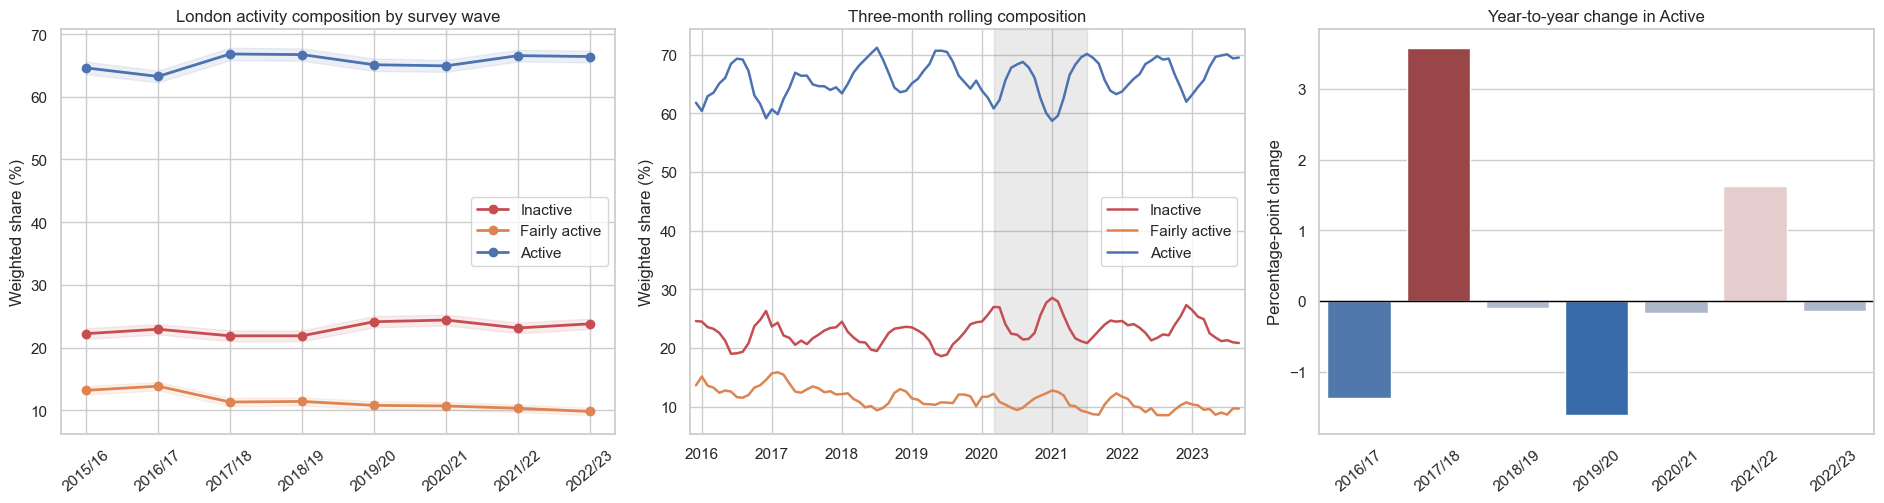

In [3]:
# Compare annual composition, smoothed monthly movement and year-to-year Active changes.
london_annual = add_rate_intervals(panels[('London', 'Annual')])
london_monthly = panels[('London', 'Monthly')].sort_values('period_start').copy()

fig, axes = plt.subplots(1, 3, figsize=(19, 5.2))
x = np.arange(len(london_annual))
for target in TARGETS:
    axes[0].plot(x, london_annual[target] * 100, marker='o', linewidth=2,
                 color=COLORS[target], label=TARGET_LABELS[target])
    axes[0].fill_between(x, london_annual[f'{target}_low'] * 100,
                         london_annual[f'{target}_high'] * 100,
                         color=COLORS[target], alpha=.10)
axes[0].set_xticks(x, london_annual['survey_wave'], rotation=40)
axes[0].set(title='London activity composition by survey wave', xlabel='', ylabel='Weighted share (%)')
axes[0].legend()

rolling = london_monthly.set_index('period_start')[TARGETS].rolling(3, center=True).mean() * 100
rolling.plot(ax=axes[1], color=[COLORS[x] for x in TARGETS], linewidth=1.8)
axes[1].axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-07-01'), color='grey', alpha=.16)
axes[1].set(title='Three-month rolling composition', xlabel='', ylabel='Weighted share (%)')
axes[1].legend([TARGET_LABELS[x] for x in TARGETS])

annual_change = london_annual[['survey_wave', 'active_rate']].copy()
annual_change['change_pp'] = annual_change['active_rate'].diff() * 100
sns.barplot(data=annual_change.dropna(), x='survey_wave', y='change_pp',
            hue='change_pp', palette='vlag', legend=False, ax=axes[2])
axes[2].axhline(0, color='black', linewidth=1)
axes[2].set(title='Year-to-year change in Active', xlabel='', ylabel='Percentage-point change')
axes[2].tick_params(axis='x', rotation=40)
fig.tight_layout()
plt.show()

Annual change can hide recurring survey-month patterns. The next figure removes each wave's mean before averaging by month-of-wave, then estimates COVID phase differences relative to the pre-COVID period while controlling for trend, seasonality and online response share.

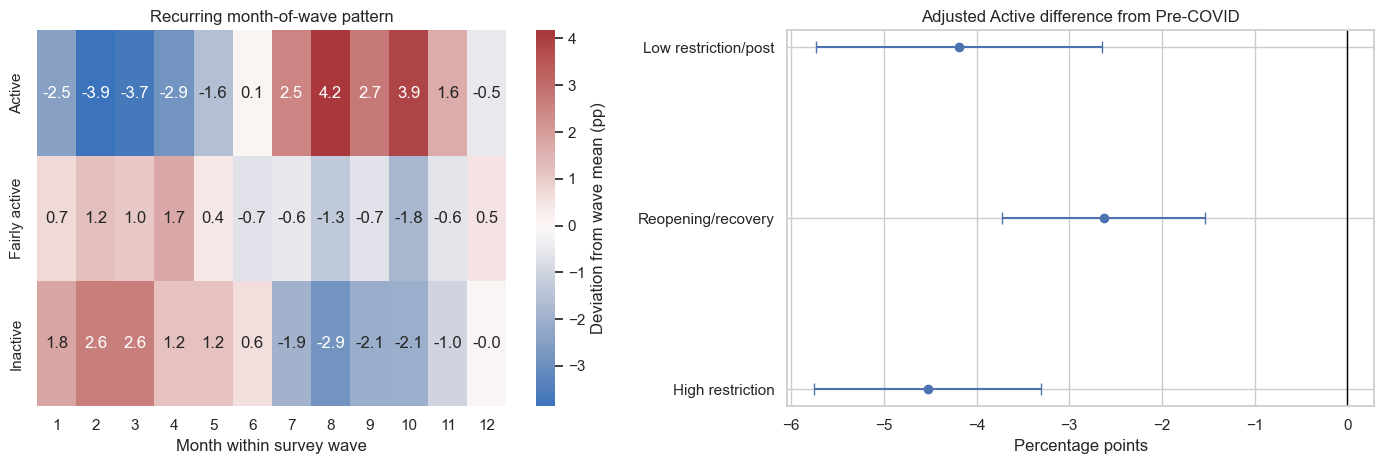

,phase,difference_pp,low,high,p_value
0,High restriction,-4.53,-5.75,-3.30,0.0
1,Reopening/recovery,-2.63,-3.73,-1.53,0.0
2,Low restriction/post,-4.19,-5.73,-2.65,0.0


In [4]:
# Separate recurring within-wave seasonality from COVID-period deviations.
seasonal_rows = []
for target in TARGETS:
    local = london_monthly[['year', 'month_of_wave', target]].copy()
    local['deviation_pp'] = (local[target] - local.groupby('year')[target].transform('mean')) * 100
    seasonal_rows.append(local.groupby('month_of_wave', as_index=False)['deviation_pp'].mean().assign(target=TARGET_LABELS[target]))
seasonal_deviation = pd.concat(seasonal_rows, ignore_index=True)

london_monthly['active_pct'] = london_monthly['active_rate'] * 100
london_monthly['time_trend'] = london_monthly['month_index'] - 1
london_monthly['covid_phase'] = np.select(
    [
        london_monthly['period_start'].le(pd.Timestamp('2020-02-01')),
        london_monthly['period_start'].le(pd.Timestamp('2021-06-01')),
        london_monthly['period_start'].le(pd.Timestamp('2022-02-01')),
    ],
    ['Pre-COVID', 'High restriction', 'Reopening/recovery'],
    default='Low restriction/post',
)
phase_order = ['Pre-COVID', 'High restriction', 'Reopening/recovery', 'Low restriction/post']
london_monthly['covid_phase'] = pd.Categorical(london_monthly['covid_phase'], categories=phase_order, ordered=True)
phase_model = smf.wls(
    'active_pct ~ time_trend + C(month_of_wave) + C(covid_phase, Treatment(reference="Pre-COVID")) + online_response_rate',
    data=london_monthly, weights=london_monthly['effective_n'],
).fit(cov_type='HAC', cov_kwds={'maxlags': 12})
phase_terms = []
for phase in phase_order[1:]:
    term = f'C(covid_phase, Treatment(reference="Pre-COVID"))[T.{phase}]'
    interval = phase_model.conf_int().loc[term]
    phase_terms.append({'phase': phase, 'difference_pp': phase_model.params[term],
                        'low': interval.iloc[0], 'high': interval.iloc[1], 'p_value': phase_model.pvalues[term]})
phase_effects = pd.DataFrame(phase_terms)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
season_heat = seasonal_deviation.pivot(index='target', columns='month_of_wave', values='deviation_pp')
sns.heatmap(season_heat, cmap='vlag', center=0, annot=True, fmt='.1f',
            cbar_kws={'label': 'Deviation from wave mean (pp)'}, ax=axes[0])
axes[0].set(title='Recurring month-of-wave pattern', xlabel='Month within survey wave', ylabel='')

axes[1].errorbar(phase_effects['difference_pp'], phase_effects['phase'],
                 xerr=[phase_effects['difference_pp'] - phase_effects['low'],
                       phase_effects['high'] - phase_effects['difference_pp']],
                 fmt='o', color='#4C72B0', capsize=4)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set(title='Adjusted Active difference from Pre-COVID', xlabel='Percentage points', ylabel='')
fig.tight_layout()
plt.show()
display(phase_effects.round({'difference_pp': 2, 'low': 2, 'high': 2, 'p_value': 3}))

# 2. Inner versus Outer London

The second level asks whether the London-wide movement was shared evenly. The first figure tracks the raw Active gap. The second standardises Inner and Outer London to the same London age distribution, separating age composition from within-age participation differences.

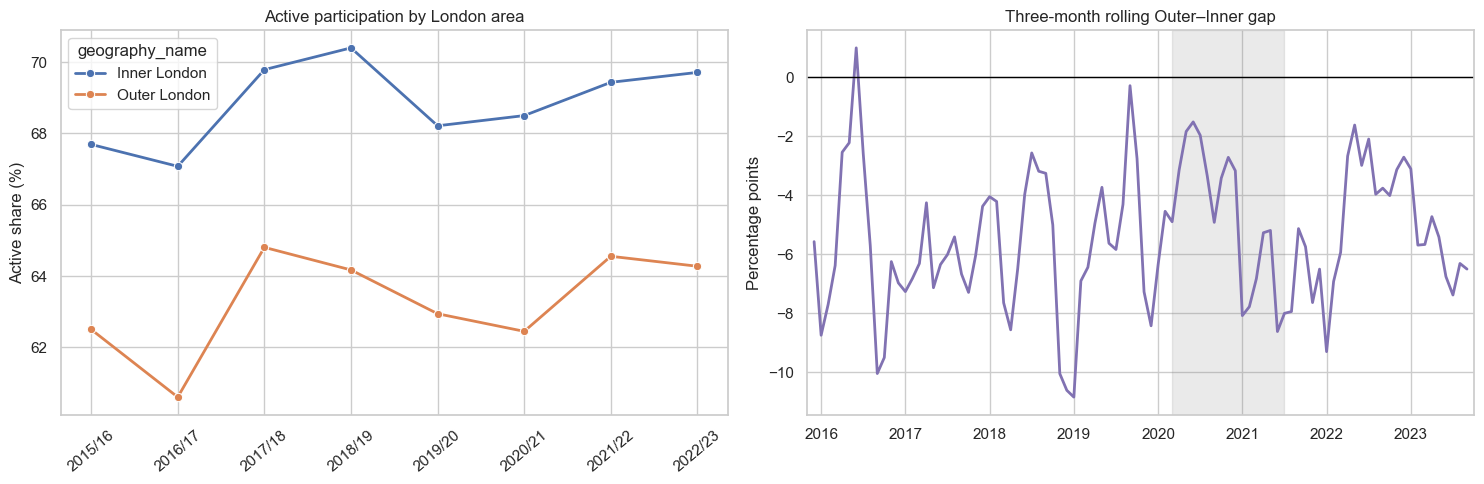

In [5]:
# Track the Inner/Outer Active gap at annual and monthly frequency.
area_annual = add_rate_intervals(panels[('Inner/Outer', 'Annual')])
area_monthly = panels[('Inner/Outer', 'Monthly')].sort_values('period_start').copy()
annual_gap = area_annual.pivot(index='survey_wave', columns='geography_name', values='active_rate')
annual_gap['Outer minus Inner'] = (annual_gap['Outer London'] - annual_gap['Inner London']) * 100
monthly_gap = area_monthly.pivot(index='period_start', columns='geography_name', values='active_rate')
monthly_gap['Outer minus Inner'] = (monthly_gap['Outer London'] - monthly_gap['Inner London']) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(data=area_annual, x='survey_wave', y=area_annual['active_rate'] * 100,
             hue='geography_name', marker='o', linewidth=2, ax=axes[0])
axes[0].set(title='Active participation by London area', xlabel='', ylabel='Active share (%)')
axes[0].tick_params(axis='x', rotation=40)
monthly_gap['Outer minus Inner'].rolling(3, center=True).mean().plot(ax=axes[1], color='#8172B2', linewidth=2)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-07-01'), color='grey', alpha=.16)
axes[1].set(title='Three-month rolling Outer–Inner gap', xlabel='', ylabel='Percentage points')
fig.tight_layout()
plt.show()

Because Inner and Outer London have different age structures, the raw gap is not automatically a behavioural gap. Direct standardisation below applies London's annual age shares to both areas; the remaining difference is the within-age component.

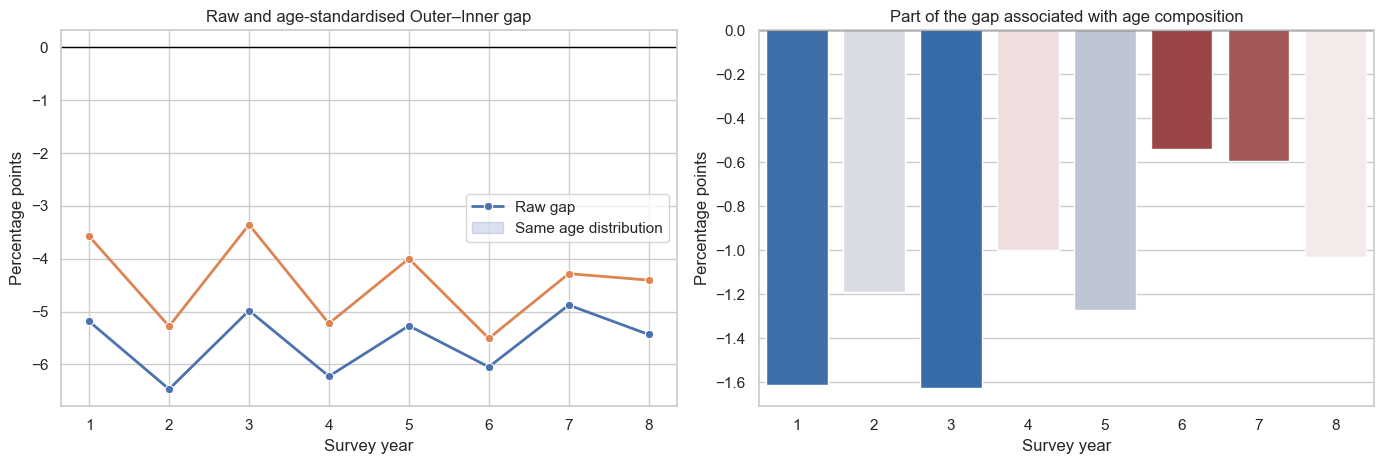

,year,raw_gap_pp,age_standardised_gap_pp,age_composition_component_pp
0,1,-5.19,-3.58,-1.61
1,2,-6.47,-5.28,-1.19
2,3,-4.98,-3.35,-1.63
3,4,-6.23,-5.23,-1.00
4,5,-5.27,-4.00,-1.27
5,6,-6.05,-5.51,-0.54
6,7,-4.88,-4.28,-0.59
7,8,-5.43,-4.40,-1.03


In [6]:
# Age-standardise each area to the same London age distribution.
age_annual = pd.read_csv(PATHS['Age'])
age_london = age_annual.loc[age_annual['geography_level'].eq('London'), ['year', 'age_band', 'population_share']]
age_area = age_annual.loc[age_annual['geography_level'].eq('InnerOuter')].merge(
    age_london.rename(columns={'population_share': 'london_age_share'}),
    on=['year', 'age_band'], validate='many_to_one',
)
standardised_area = age_area.assign(
    weighted_active=lambda x: x['london_age_share'] * x['active_rate']
).groupby(['year', 'geography_name'], as_index=False)['weighted_active'].sum()
standardised_gap = standardised_area.pivot(index='year', columns='geography_name', values='weighted_active')
standardised_gap['age_standardised_gap_pp'] = (
    standardised_gap['Outer London'] - standardised_gap['Inner London']
) * 100
raw_gap_year = area_annual.pivot(index='year', columns='geography_name', values='active_rate')
gap_decomposition = pd.DataFrame({
    'raw_gap_pp': (raw_gap_year['Outer London'] - raw_gap_year['Inner London']) * 100,
    'age_standardised_gap_pp': standardised_gap['age_standardised_gap_pp'],
}).reset_index()
gap_decomposition['age_composition_component_pp'] = (
    gap_decomposition['raw_gap_pp'] - gap_decomposition['age_standardised_gap_pp']
)
gap_long = gap_decomposition.melt('year', var_name='measure', value_name='gap_pp')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
sns.lineplot(data=gap_long.loc[gap_long['measure'].isin(['raw_gap_pp', 'age_standardised_gap_pp'])],
             x='year', y='gap_pp', hue='measure', marker='o', linewidth=2, ax=axes[0])
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set(title='Raw and age-standardised Outer–Inner gap', xlabel='Survey year', ylabel='Percentage points')
axes[0].legend(['Raw gap', 'Same age distribution'], title='')
sns.barplot(data=gap_decomposition, x='year', y='age_composition_component_pp',
            hue='age_composition_component_pp', palette='vlag', legend=False, ax=axes[1])
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set(title='Part of the gap associated with age composition', xlabel='Survey year', ylabel='Percentage points')
fig.tight_layout()
plt.show()
display(gap_decomposition.round(2))

# 3. London boroughs

The borough level asks three linked questions: are high-activity boroughs consistently high, which boroughs changed most, and are neighbouring boroughs unusually similar? Rankings are shown with uncertainty so that small differences are not overinterpreted.

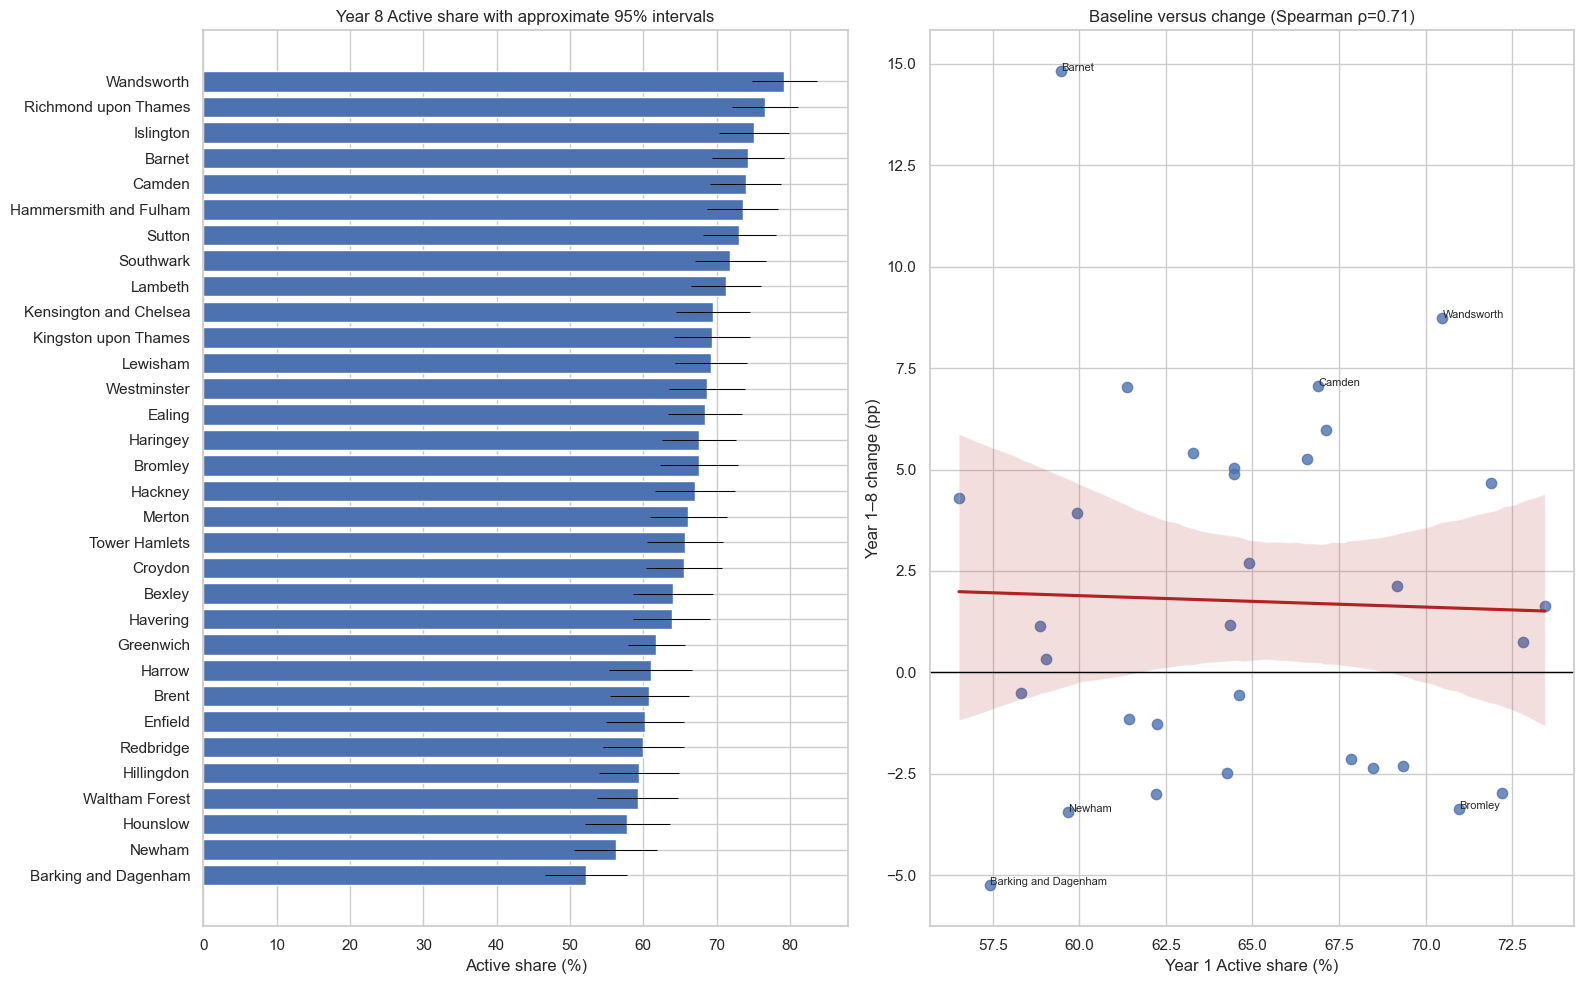

,direction,geography_name,start_active_pct,latest_active_pct,change_pp
1,Largest increase,Barnet,59.47,74.29,14.82
30,Largest increase,Wandsworth,70.49,79.23,8.74
5,Largest increase,Camden,66.90,73.96,7.06
7,Largest increase,Ealing,61.37,68.41,7.04
27,Largest increase,Sutton,67.13,73.10,5.97
0,Largest decrease,Barking and Dagenham,57.42,52.16,-5.25
23,Largest decrease,Newham,59.66,56.21,-3.45
4,Largest decrease,Bromley,70.96,67.58,-3.37
29,Largest decrease,Waltham Forest,62.21,59.21,-3.00
21,Largest decrease,Lewisham,72.21,69.24,-2.97


In [7]:
# Compare Year 8 levels with eight-year change and test rank persistence.
borough_annual = add_rate_intervals(panels[('Borough', 'Annual')])
start = borough_annual.loc[borough_annual['year'].eq(1)].set_index('geography_code')
latest = borough_annual.loc[borough_annual['year'].eq(8)].set_index('geography_code')
borough_change = pd.DataFrame({
    'geography_name': latest['geography_name'],
    'start_active_pct': start['active_rate'] * 100,
    'latest_active_pct': latest['active_rate'] * 100,
    'change_pp': (latest['active_rate'] - start['active_rate']) * 100,
    'latest_low_pct': latest['active_rate_low'] * 100,
    'latest_high_pct': latest['active_rate_high'] * 100,
}).reset_index()
rank_correlation, rank_p = spearmanr(borough_change['start_active_pct'], borough_change['latest_active_pct'])
change_fit = smf.ols('change_pp ~ start_active_pct', data=borough_change).fit()

fig, axes = plt.subplots(1, 2, figsize=(16, 10))
ranked = borough_change.sort_values('latest_active_pct')
axes[0].barh(ranked['geography_name'], ranked['latest_active_pct'], color='#4C72B0')
axes[0].errorbar(ranked['latest_active_pct'], ranked['geography_name'],
                 xerr=[ranked['latest_active_pct'] - ranked['latest_low_pct'],
                       ranked['latest_high_pct'] - ranked['latest_active_pct']],
                 fmt='none', color='black', linewidth=.7)
axes[0].set(title='Year 8 Active share with approximate 95% intervals', xlabel='Active share (%)', ylabel='')

sns.regplot(data=borough_change, x='start_active_pct', y='change_pp', ax=axes[1],
            scatter_kws={'s': 55, 'alpha': .8}, line_kws={'color': 'firebrick'})
for _, row in borough_change.nlargest(3, 'change_pp').iterrows():
    axes[1].annotate(row['geography_name'], (row['start_active_pct'], row['change_pp']), fontsize=8)
for _, row in borough_change.nsmallest(3, 'change_pp').iterrows():
    axes[1].annotate(row['geography_name'], (row['start_active_pct'], row['change_pp']), fontsize=8)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set(title=f'Baseline versus change (Spearman ρ={rank_correlation:.2f})',
            xlabel='Year 1 Active share (%)', ylabel='Year 1–8 change (pp)')
fig.tight_layout()
plt.show()

borough_extremes = pd.concat([
    borough_change.nlargest(5, 'change_pp').assign(direction='Largest increase'),
    borough_change.nsmallest(5, 'change_pp').assign(direction='Largest decrease'),
])
display(borough_extremes[['direction', 'geography_name', 'start_active_pct', 'latest_active_pct', 'change_pp']].round(2))

Maps can reveal structure that rankings miss. The next step maps both Year 8 levels and eight-year changes, then calculates a permutation Moran's I using polygon neighbours. A positive statistic indicates that nearby boroughs tend to have similar values.

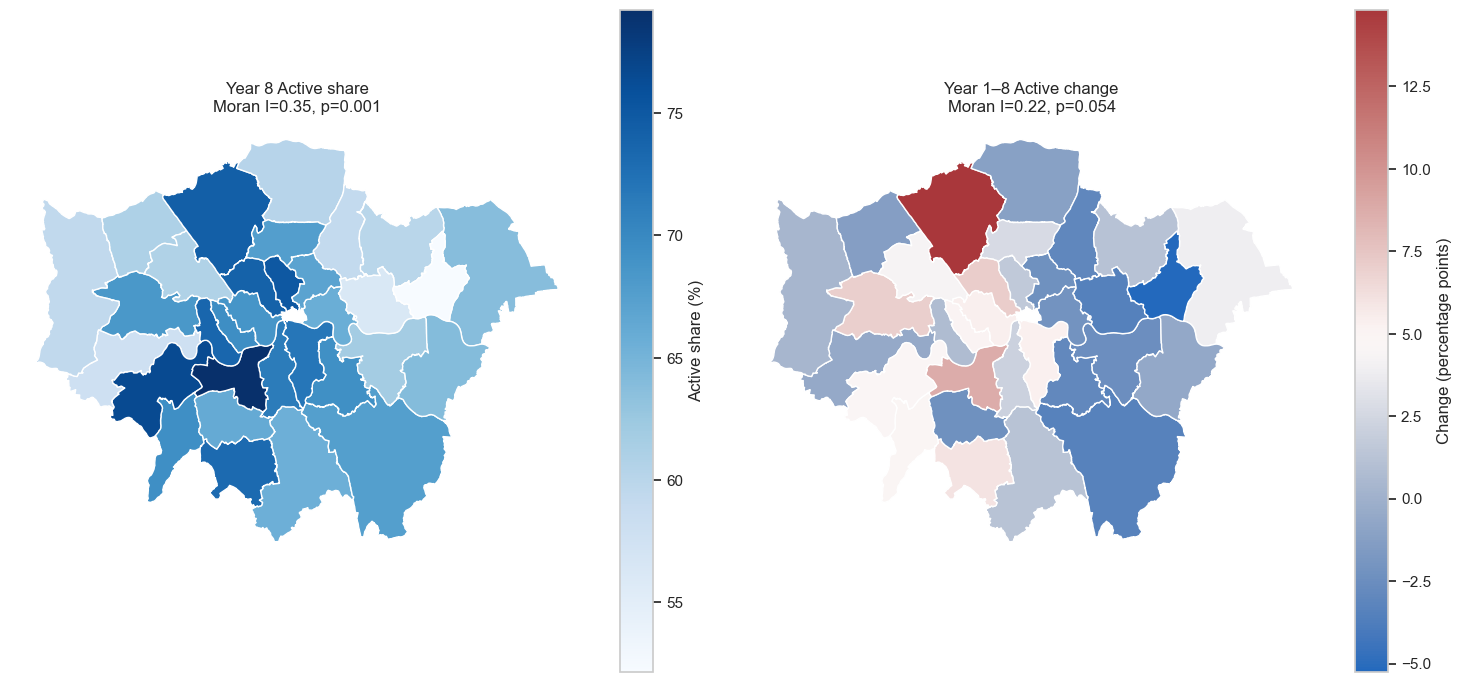

In [8]:
# Map levels and changes and assess neighbour similarity without saving the figure.
boundaries = gpd.read_file(PATHS['Boundary'])[['gss_code', 'name', 'geometry']]
borough_map = boundaries.merge(borough_change, left_on='gss_code', right_on='geography_code', validate='one_to_one')
assert len(borough_map) == 32

def moran_permutation(geodata, value_column, repeats=999, seed=2026):
    '''Calculate row-standardised Moran's I and a two-sided permutation p-value.'''
    values = geodata[value_column].to_numpy(float)
    centred = values - values.mean()
    neighbours = np.array([[a.touches(b) for b in geodata.geometry] for a in geodata.geometry], dtype=float)
    np.fill_diagonal(neighbours, 0)
    row_sums = neighbours.sum(axis=1, keepdims=True)
    weights = np.divide(neighbours, row_sums, out=np.zeros_like(neighbours), where=row_sums > 0)
    statistic = len(values) / weights.sum() * (weights * centred[:, None] * centred[None, :]).sum() / np.square(centred).sum()
    rng = np.random.default_rng(seed)
    null = []
    for _ in range(repeats):
        permuted = rng.permutation(centred)
        null.append(len(values) / weights.sum() * (weights * permuted[:, None] * permuted[None, :]).sum() / np.square(permuted).sum())
    null = np.asarray(null)
    p_value = (1 + np.sum(np.abs(null) >= abs(statistic))) / (repeats + 1)
    return statistic, p_value

moran_level, moran_level_p = moran_permutation(borough_map, 'latest_active_pct')
moran_change, moran_change_p = moran_permutation(borough_map, 'change_pp')

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
borough_map.plot(column='latest_active_pct', cmap='Blues', legend=True, edgecolor='white', ax=axes[0],
                 legend_kwds={'label': 'Active share (%)'})
axes[0].set_title(f'Year 8 Active share\nMoran I={moran_level:.2f}, p={moran_level_p:.3f}')
borough_map.plot(column='change_pp', cmap='vlag', legend=True, edgecolor='white', ax=axes[1],
                 legend_kwds={'label': 'Change (percentage points)'})
axes[1].set_title(f'Year 1–8 Active change\nMoran I={moran_change:.2f}, p={moran_change_p:.3f}')
for ax in axes:
    ax.set_axis_off()
fig.tight_layout()
plt.show()

A contextual variable can distinguish boroughs from one another without explaining change within the same borough. To expose that difference, the next chart compares ordinary correlations of eight-year borough means with correlations after removing each borough's own mean.

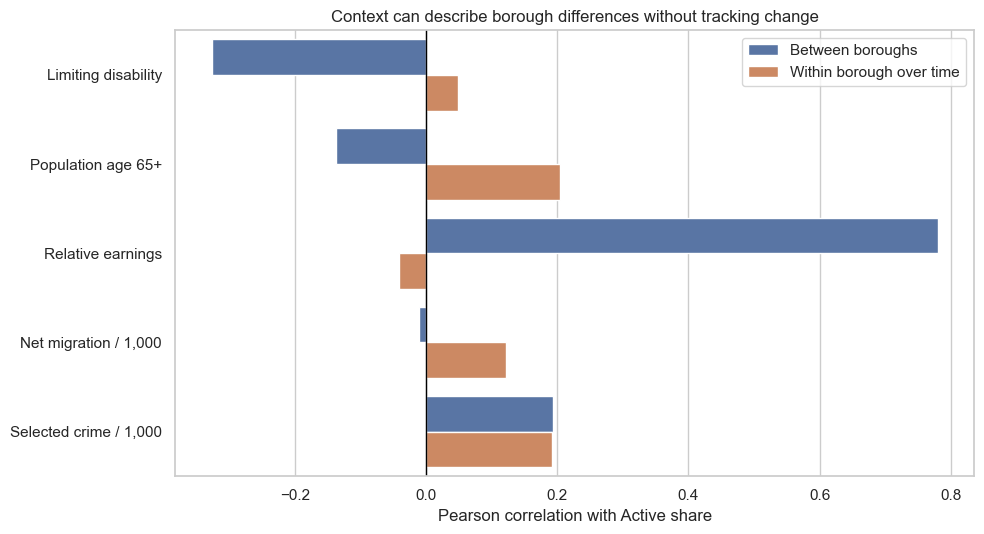

comparison,Between boroughs,Within borough over time
feature,,
Limiting disability,-0.33,0.05
"Net migration / 1,000",-0.01,0.12
Population age 65+,-0.14,0.20
Relative earnings,0.78,-0.04
"Selected crime / 1,000",0.19,0.19


In [9]:
# Contrast between-borough and within-borough associations with Active participation.
context_features = {
    'Limiting disability': 'limiting_disability_rate',
    'Population age 65+': 'population_age_65_plus_rate',
    'Relative earnings': 'earnings_relative_to_london',
    'Net migration / 1,000': 'net_migration_per_1000',
    'Selected crime / 1,000': 'selected_recorded_crime_rate_per_1000',
}
between = borough_annual.groupby('geography_code')[[*context_features.values(), 'active_rate']].mean()
demeaned = borough_annual[[*context_features.values(), 'active_rate']].copy()
for column in demeaned:
    demeaned[column] = borough_annual[column] - borough_annual.groupby('geography_code')[column].transform('mean')
association_rows = []
for label, feature in context_features.items():
    association_rows.extend([
        {'feature': label, 'comparison': 'Between boroughs', 'correlation': between[feature].corr(between['active_rate'])},
        {'feature': label, 'comparison': 'Within borough over time', 'correlation': demeaned[feature].corr(demeaned['active_rate'])},
    ])
context_associations = pd.DataFrame(association_rows)

plt.figure(figsize=(10, 5.5))
sns.barplot(data=context_associations, y='feature', x='correlation', hue='comparison', palette=['#4C72B0', '#DD8452'])
plt.axvline(0, color='black', linewidth=1)
plt.title('Context can describe borough differences without tracking change')
plt.xlabel('Pearson correlation with Active share')
plt.ylabel('')
plt.legend(title='')
plt.tight_layout()
plt.show()
display(context_associations.pivot(index='feature', columns='comparison', values='correlation').round(2))

# 4. Respondent-level inequalities

Aggregate panels cannot show whether trends are concentrated in particular demographic groups. The final level loads only the respondent fields needed for age, disability, Inner/Outer London, survey mode and activity outcome. Survey weights are retained; no individual is treated as a longitudinal repeat because the files contain repeated cross-sections, not a person panel.

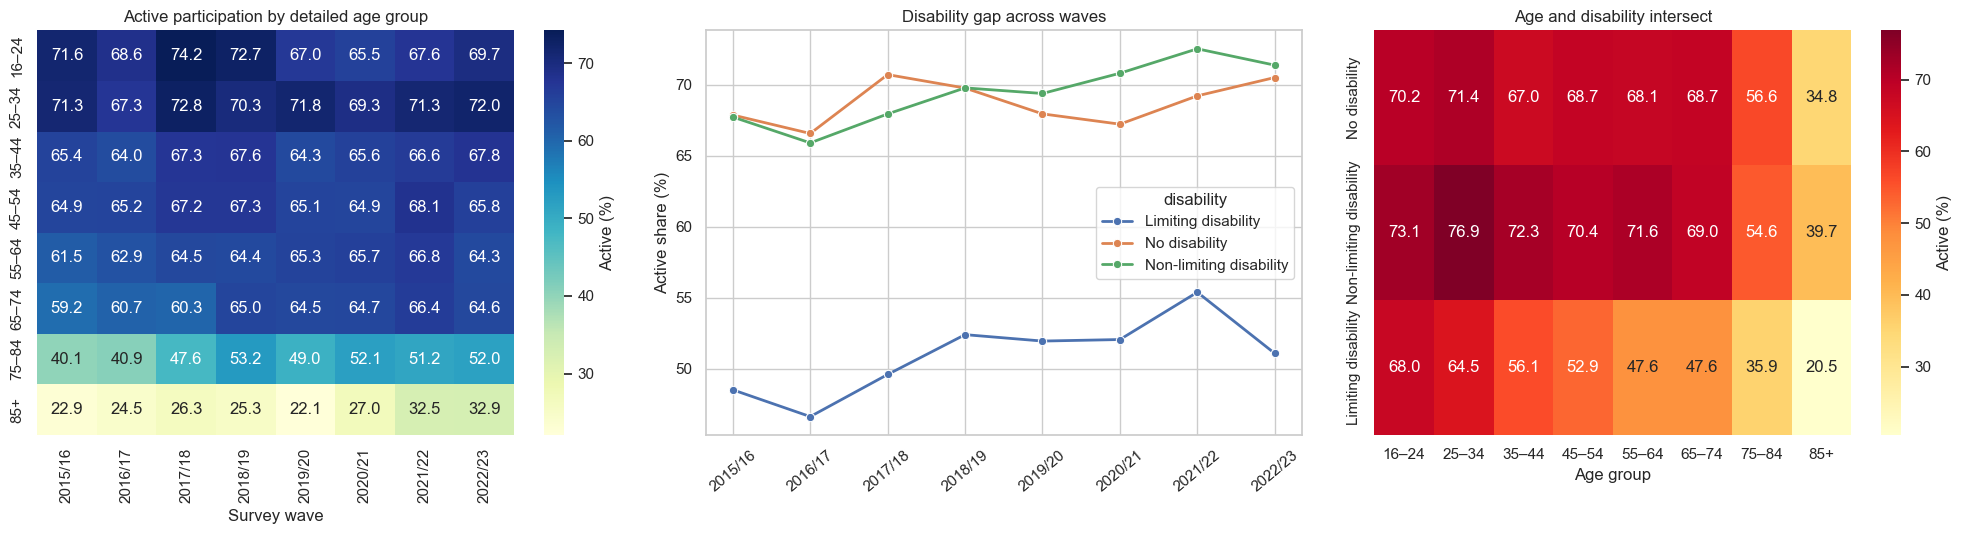

In [10]:
# Load a compact respondent view and create readable categories.
respondent_columns = [
    'year', 'survey_wave', 'Age9', 'Disab3', 'mode', 'MEMS7GR_ALL', 'wt_final',
    'inner_outer', 'borough', 'annual_analysis_eligible',
]
respondents = pd.read_csv(PATHS['Respondent'], usecols=respondent_columns, low_memory=False)
respondents = respondents.loc[respondents['annual_analysis_eligible']].copy()
respondents['active_binary'] = respondents['MEMS7GR_ALL'].eq(2).astype(int)
age_labels = {2: '16–24', 3: '25–34', 4: '35–44', 5: '45–54', 6: '55–64', 7: '65–74', 8: '75–84', 9: '85+'}
disability_labels = {1: 'Limiting disability', 2: 'Non-limiting disability', 3: 'No disability'}
mode_labels = {1: 'Online', 2: 'Paper'}
respondents['age_group'] = respondents['Age9'].map(age_labels)
respondents['disability'] = respondents['Disab3'].map(disability_labels)
respondents['response_mode'] = respondents['mode'].map(mode_labels)

age_rates = weighted_group_rate(respondents.dropna(subset=['age_group']), ['survey_wave', 'age_group'])
disability_rates = weighted_group_rate(respondents.dropna(subset=['disability']), ['survey_wave', 'disability'])
intersection_rates = weighted_group_rate(
    respondents.dropna(subset=['age_group', 'disability']), ['age_group', 'disability']
)

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
age_heat = age_rates.pivot(index='age_group', columns='survey_wave', values='active_rate').reindex(age_labels.values()) * 100
sns.heatmap(age_heat, cmap='YlGnBu', annot=True, fmt='.1f', cbar_kws={'label': 'Active (%)'}, ax=axes[0])
axes[0].set(title='Active participation by detailed age group', xlabel='Survey wave', ylabel='')
sns.lineplot(data=disability_rates, x='survey_wave', y=disability_rates['active_rate'] * 100,
             hue='disability', marker='o', linewidth=2, ax=axes[1])
axes[1].set(title='Disability gap across waves', xlabel='', ylabel='Active share (%)')
axes[1].tick_params(axis='x', rotation=40)
intersection_heat = intersection_rates.pivot(index='disability', columns='age_group', values='active_rate').reindex(
    index=['No disability', 'Non-limiting disability', 'Limiting disability'], columns=age_labels.values()
) * 100
sns.heatmap(intersection_heat, cmap='YlOrRd', annot=True, fmt='.1f', cbar_kws={'label': 'Active (%)'}, ax=axes[2])
axes[2].set(title='Age and disability intersect', xlabel='Age group', ylabel='')
fig.tight_layout()
plt.show()

Raw subgroup gaps can reflect different age, location, year and response-mode composition. A weighted logistic model now estimates adjusted associations with being Active. Odds ratios below one indicate lower adjusted odds than the named reference group; survey mode is included only as a sensitivity control and should not be interpreted causally.

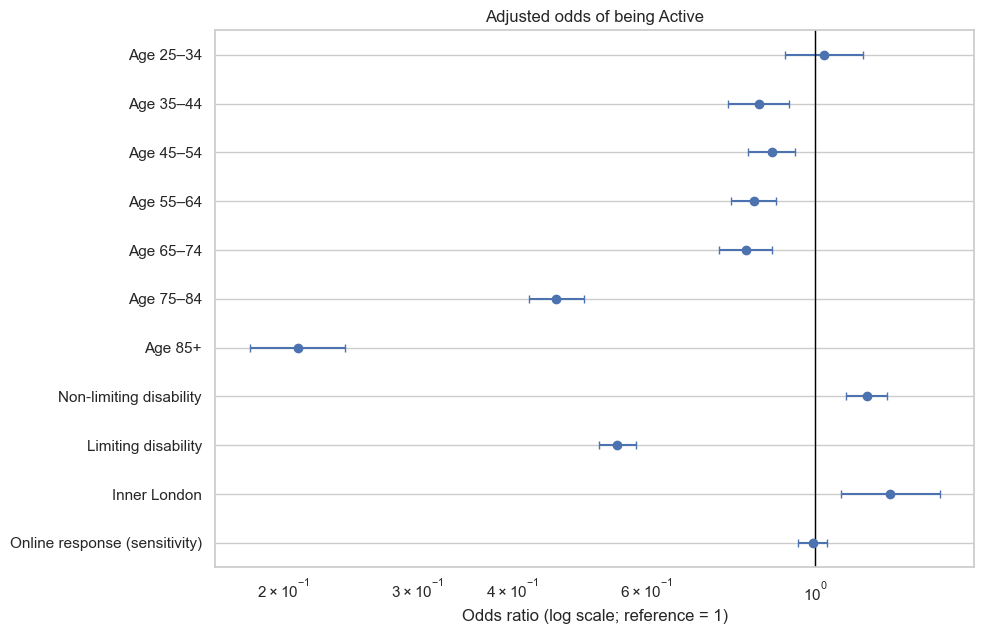

,factor,odds_ratio,low,high,p_value
0,Age 25–34,1.03,0.91,1.15,0.659
1,Age 35–44,0.84,0.77,0.92,0.000
2,Age 45–54,0.88,0.82,0.94,0.000
3,Age 55–64,0.83,0.78,0.89,0.000
4,Age 65–74,0.81,0.75,0.88,0.000
5,Age 75–84,0.46,0.42,0.50,0.000
6,Age 85+,0.21,0.18,0.24,0.000
7,Non-limiting disability,1.17,1.10,1.24,0.000
8,Limiting disability,0.55,0.52,0.58,0.000
9,Inner London,1.25,1.08,1.46,0.003


In [11]:
# Fit a multivariable weighted logistic model and plot adjusted odds ratios.
model_data = respondents.dropna(subset=['age_group', 'disability', 'response_mode', 'inner_outer', 'borough']).copy()
model_data['age_group'] = pd.Categorical(model_data['age_group'], categories=list(age_labels.values()), ordered=True)
model_data['disability'] = pd.Categorical(
    model_data['disability'], categories=['No disability', 'Non-limiting disability', 'Limiting disability']
)
model_data['response_mode'] = pd.Categorical(model_data['response_mode'], categories=['Paper', 'Online'])
model_data['inner_outer'] = pd.Categorical(model_data['inner_outer'], categories=['Outer London', 'Inner London'])
model_data['analysis_weight'] = model_data['wt_final'] / model_data['wt_final'].mean()
individual_model = smf.gee(
    'active_binary ~ C(age_group, Treatment(reference="16–24")) + '
    'C(disability, Treatment(reference="No disability")) + '
    'C(inner_outer, Treatment(reference="Outer London")) + '
    'C(response_mode, Treatment(reference="Paper")) + C(year)',
    groups='borough', data=model_data, family=sm.families.Binomial(),
    weights=model_data['analysis_weight'], cov_struct=sm.cov_struct.Independence(),
).fit()

coefficient_labels = {
    'C(age_group, Treatment(reference="16–24"))[T.25–34]': 'Age 25–34',
    'C(age_group, Treatment(reference="16–24"))[T.35–44]': 'Age 35–44',
    'C(age_group, Treatment(reference="16–24"))[T.45–54]': 'Age 45–54',
    'C(age_group, Treatment(reference="16–24"))[T.55–64]': 'Age 55–64',
    'C(age_group, Treatment(reference="16–24"))[T.65–74]': 'Age 65–74',
    'C(age_group, Treatment(reference="16–24"))[T.75–84]': 'Age 75–84',
    'C(age_group, Treatment(reference="16–24"))[T.85+]': 'Age 85+',
    'C(disability, Treatment(reference="No disability"))[T.Non-limiting disability]': 'Non-limiting disability',
    'C(disability, Treatment(reference="No disability"))[T.Limiting disability]': 'Limiting disability',
    'C(inner_outer, Treatment(reference="Outer London"))[T.Inner London]': 'Inner London',
    'C(response_mode, Treatment(reference="Paper"))[T.Online]': 'Online response (sensitivity)',
}
intervals = individual_model.conf_int()
odds_rows = []
for term, label in coefficient_labels.items():
    odds_rows.append({
        'factor': label, 'odds_ratio': np.exp(individual_model.params[term]),
        'low': np.exp(intervals.loc[term, 0]), 'high': np.exp(intervals.loc[term, 1]),
        'p_value': individual_model.pvalues[term],
    })
adjusted_odds = pd.DataFrame(odds_rows)

plt.figure(figsize=(10, 6.5))
ordered = adjusted_odds.iloc[::-1]
plt.errorbar(ordered['odds_ratio'], ordered['factor'],
             xerr=[ordered['odds_ratio'] - ordered['low'], ordered['high'] - ordered['odds_ratio']],
             fmt='o', color='#4C72B0', capsize=3)
plt.axvline(1, color='black', linewidth=1)
plt.xscale('log')
plt.title('Adjusted odds of being Active')
plt.xlabel('Odds ratio (log scale; reference = 1)')
plt.ylabel('')
plt.tight_layout()
plt.show()
display(adjusted_odds.round({'odds_ratio': 2, 'low': 2, 'high': 2, 'p_value': 3}))

# Final findings

## 1. London overall

London's Active share was 64.6% in Year 1 and 66.4% in Year 8, so the eight-year net movement was modest (+1.8 percentage points) rather than a smooth upward trend. The largest annual rise was +3.6 points in 2017/18 and the largest fall was -1.6 points in 2019/20. The composition changed more clearly than the headline: Fairly Active fell from 13.2% to 9.8%, while Inactive rose from 22.2% to 23.8%.

The monthly evidence reveals structure hidden by annual averages. Active is typically lowest in month 2 of a survey wave (-3.9 points relative to that wave's mean) and highest in month 8 (+4.2 points). After adjusting for trend, recurring month and online response, Active remained lower than the pre-COVID period in the high-restriction phase (-4.5 points, 95% CI -5.8 to -3.3), reopening (-2.6, -3.7 to -1.5) and the later low-restriction/post period (-4.2, -5.7 to -2.7). This is evidence of a persistent temporal break, not proof that COVID caused the whole difference: phase and calendar time cannot be fully separated in one London time series.

## 2. Inner and Outer London

Inner London had the higher Active share in every year. The raw Inner advantage averaged 5.6 points and ranged from 4.9 to 6.5 points. Giving Inner and Outer London the same age distribution reduced the average advantage to 4.5 points. Age composition therefore accounts for about 1.1 points, or 20% of the observed gap; roughly 80% remains after age standardisation. The gap is consequently not just an artefact of Inner London's younger population.

## 3. London boroughs

Borough positions are persistent but not fixed: the Year 1 versus Year 8 rank correlation is 0.71 (p<0.001). Barnet recorded the largest estimated rise (+14.8 points), followed by Wandsworth (+8.7), while Barking and Dagenham had the largest fall (-5.3). Because borough intervals are much wider than the London interval, these extremes should be read with their displayed uncertainty rather than as exact league-table positions.

Year 8 levels show clear neighbour similarity (Moran's I=0.35, permutation p=0.001), whereas eight-year changes are weaker and only borderline (I=0.22, p=0.054). Geography therefore organises the level of participation more strongly than the direction of recent change. Relative earnings strongly distinguish high- and low-activity boroughs between places (r=0.78), but do not track improvement within the same borough over time (r=-0.04). The same between/within contrast appears for limiting disability (-0.33 versus 0.05). These are contextual markers of place, not convincing short-run change mechanisms.

## 4. Respondents

Age differences are nonlinear. In Year 8, Active participation was about 70% at ages 16–24, 72% at 25–34 and 68% at 35–44, then declined to 52% at 75–84 and 33% at 85+. The oldest groups nevertheless improved substantially from Year 1: +11.8 points at 75–84 and +9.9 at 85+. Limiting disability remained a larger divide: its Active share rose from 48.5% to 51.1%, compared with 70.5% among respondents reporting no disability in Year 8.

In the adjusted weighted model, limiting disability was associated with around 45% lower odds of being Active (OR 0.55, 95% CI 0.52–0.58), age 85+ with around 79% lower odds than age 16–24 (OR 0.21, 0.18–0.24), and Inner London with 25% higher odds than Outer London (OR 1.25, 1.08–1.46). Online response was essentially null after adjustment (OR 0.99, 0.95–1.04), supporting its treatment as a sensitivity control rather than a substantive driver. These are adjusted associations, not causal effects.

## Synthesis

The four levels tell a coherent story that the London average alone misses: the citywide headline changed little, but there was a temporal break, a durable Inner/Outer divide not explained by age, spatially clustered borough inequality, and especially large respondent-level disadvantages linked to limiting disability and old age. The strongest new finding is the separation between **place level** and **place change**: affluent boroughs tend to be more active, yet annual earnings movements do not accompany annual activity movements. Policy interpretation should therefore prioritise persistent population and place barriers over assuming that short-run contextual correlations identify what caused change.